# HouseHolding Dataset (Task 1)


In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pickle

sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 100

In [14]:
housing = fetch_california_housing(as_frame=True)
df = housing.frame
print(df.shape)
df.head()

(20640, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [15]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [16]:
df.isnull().sum()

MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

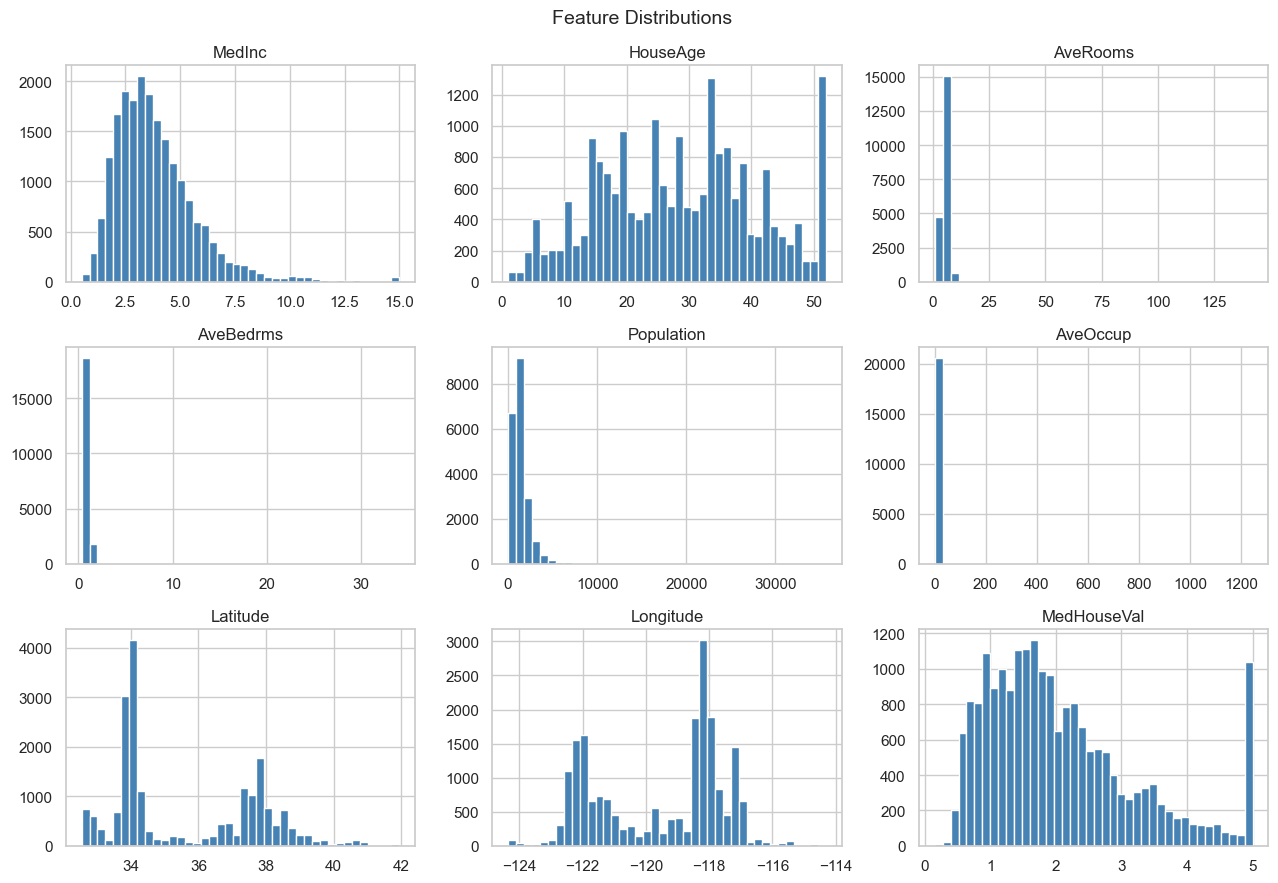

In [17]:
df.hist(figsize=(13, 9), bins=40, color='steelblue', edgecolor='white')
plt.suptitle('Feature Distributions', fontsize=14)
plt.tight_layout()
plt.show()

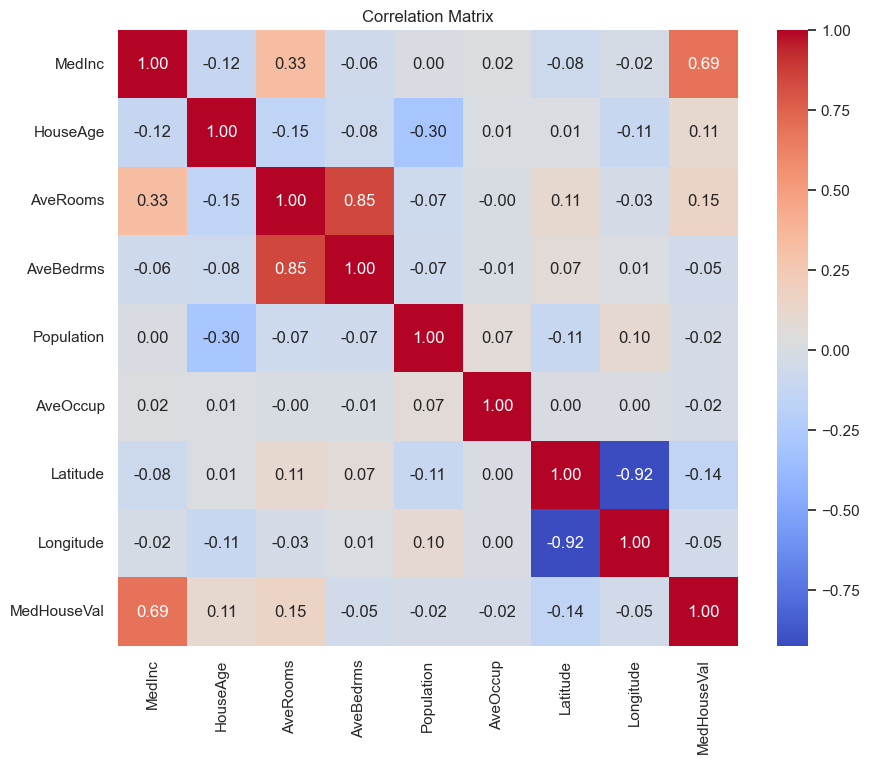

In [18]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

In [19]:
X = df.drop(columns=['MedHouseVal'])
y = df['MedHouseVal']

print(X.shape, y.shape)

(20640, 8) (20640,)


In [22]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape, X_test.shape)

(16512, 8) (4128, 8)


In [24]:
model = LinearRegression()
model.fit(X_train, y_train)
print("done")

done


In [25]:
coef_df = pd.DataFrame({'Feature': X.columns, 'Coefficient': model.coef_})
coef_df.sort_values('Coefficient', key=abs, ascending=False)

,Feature,Coefficient
3,AveBedrms,0.783145
0,MedInc,0.448675
7,Longitude,-0.433708
6,Latitude,-0.419792
2,AveRooms,-0.123323
1,HouseAge,0.009724
5,AveOccup,-0.003526
4,Population,-0.000002


In [28]:
y_pred = model.predict(X_test)

mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R2   : {r2:.4f}")

MAE  : 0.5332
RMSE : 0.7456
R2   : 0.5758


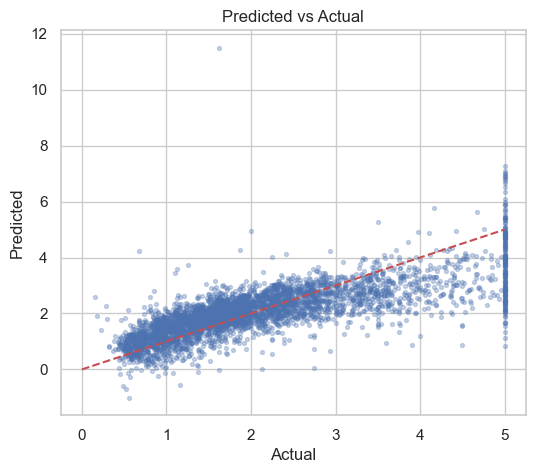

In [29]:
plt.figure(figsize=(6, 5))
plt.scatter(y_test, y_pred, alpha=0.3, s=8)
plt.plot([0, 5], [0, 5], 'r--')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Predicted vs Actual')
plt.show()

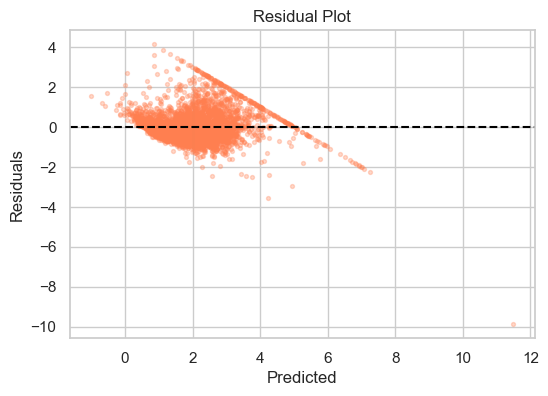

In [30]:
residuals = y_test - y_pred

plt.figure(figsize=(6, 4))
plt.scatter(y_pred, residuals, alpha=0.3, s=8, color='coral')
plt.axhline(0, color='black', ls='--')
plt.xlabel('Predicted')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.show()

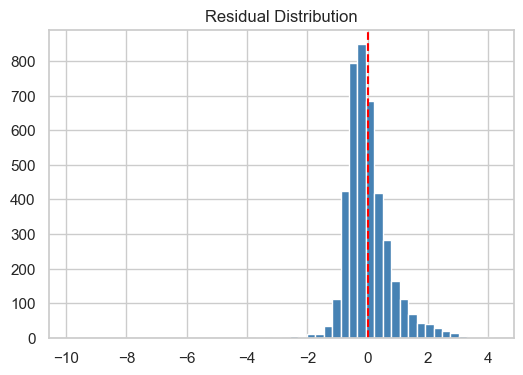

In [31]:
plt.figure(figsize=(6, 4))
pd.Series(residuals.values).hist(bins=50, color='steelblue', edgecolor='white')
plt.axvline(0, color='red', ls='--')
plt.title('Residual Distribution')
plt.show()

In [32]:
with open('model.pkl', 'wb') as f:
    pickle.dump(model, f)

print("model saved")

model saved


In [1]:
import os
print(os.getcwd())

C:\Users\dr029


In [2]:
import nbformat

with open("Task1.ipynb", "r", encoding="utf-8") as f:
    nb = nbformat.read(f, as_version=4)

print("Notebook is valid!")

FileNotFoundError: [Errno 2] No such file or directory: 'Task1.ipynb'

In [3]:
import os
print(os.listdir())

['.gemini', '.ipynb_checkpoints', '.ipython', '.jupyter', '.matplotlib', '.python_history', '.vscode', '.vscode-shared', 'alpha-vantage.csv', 'AppData', 'Application Data', 'Contacts', 'Cookies', 'Documents', 'Downloads', 'Favorites', 'Links', 'Local Settings', 'model.pkl', 'Music', 'My Documents', 'NetHood', 'NTUSER.DAT', 'ntuser.dat.LOG1', 'ntuser.dat.LOG2', 'NTUSER.DAT{e1a32212-65e5-11f0-b65f-50bbb5ab136f}.TM.blf', 'NTUSER.DAT{e1a32212-65e5-11f0-b65f-50bbb5ab136f}.TMContainer00000000000000000001.regtrans-ms', 'NTUSER.DAT{e1a32212-65e5-11f0-b65f-50bbb5ab136f}.TMContainer00000000000000000002.regtrans-ms', 'ntuser.ini', 'OneDrive', 'PrintHood', 'Recent', 'Saved Games', 'scikit_learn_data', 'Searches', 'SendTo', 'Start Menu', 'Task 1.ipynb', 'Templates', 'Untitled.ipynb', 'Untitled1.ipynb', 'Untitled2.ipynb', 'Untitled3.ipynb', 'Untitled4.ipynb', 'Videos']


In [4]:
import nbformat

with open("Task 1.ipynb", "r", encoding="utf-8") as f:
    nb = nbformat.read(f, as_version=4)

print("Notebook is valid!")

Notebook is valid!


In [5]:
import os
print(os.getcwd())


C:\Users\dr029
